<a href="https://colab.research.google.com/github/narayananxyz/deep_learning/blob/main/elective_project_digit_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load tensorflow
And print the version

In [ ]:
!pip install tensorflow
!pip install h5py

In [1]:
import tensorflow as tf
tf.__version__
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import h5py


In [2]:
import matplotlib.pyplot as plt

def plot_training(history, test_acc, test_loss):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Accuracy
    ax1.plot(history.history['accuracy'],     label='Train')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.axhline(y=test_acc, color='r', linestyle='--', label=f'Test: {test_acc:.4f}')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    # Loss
    ax2.plot(history.history['loss'],     label='Train')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.axhline(y=test_loss, color='r', linestyle='--', label=f'Test: {test_loss:.4f}')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.suptitle(f'Final Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}')
    plt.tight_layout()
    plt.show()



# Import Dataset

In this case are loading the dataset from a file. This is alaready formatted data set. looks like xtrain is set at 42k records and xval is set at 60k and x test is 18k. This is unusual for x_val, but as the problem states it is done for compute efficiency.

In [3]:
with h5py.File("/content/drive/MyDrive/mitcourse/elective/SVHN_single_grey1.h5", "r") as f:
    X_train = np.array(f['X_train'])
    y_train = np.array(f['y_train'])
    X_val   = np.array(f['X_val'])
    y_val   = np.array(f['y_val'])
    X_test  = np.array(f['X_test'])
    y_test  = np.array(f['y_test'])

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (42000, 32, 32)
y_train: (42000,)
X_val:   (60000, 32, 32)
y_val:   (60000,)
X_test:  (18000, 32, 32)
y_test:  (18000,)


# ANN Attempt 1

Let's just create a model with the default dataset and 2 hidden layers and see it how it goes.

In [24]:
tf.keras.backend.clear_session()

model = keras.Sequential([
    keras.Input(shape=(32, 32)),      # ← clean way in Keras 3
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# model.summary()

Let's compile the model and train

In [25]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.1624 - loss: 11.0842 - val_accuracy: 0.3115 - val_loss: 1.9886
Epoch 2/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.3919 - loss: 1.8551 - val_accuracy: 0.4781 - val_loss: 1.5855
Epoch 3/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5227 - loss: 1.4888 - val_accuracy: 0.5426 - val_loss: 1.4283
Epoch 4/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5735 - loss: 1.3590 - val_accuracy: 0.5977 - val_loss: 1.2949
Epoch 5/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5954 - loss: 1.2955 - val_accuracy: 0.6043 - val_loss: 1.2915
Epoch 6/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6149 - loss: 1.2361 - val_accuracy: 0.6383 - val_loss: 1.1464
Epoch 7/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6212 - loss: 1.2178 - val_accuracy: 0.6171 - val_loss: 1.2239
Epoch 8/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6387 - loss: 1.1581 - val_accuracy: 

Let's test using model.evaluate

In [27]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss:     {test_loss:.4f}")

Test accuracy: 0.6982
Test loss:     0.9910


### ANN - Attempt 1 Observations

We could get uupt to 72% in 20 epocs

# ANN - Attempt 2

First attempt is to normalize and try again.

In [28]:
# Normalize to 0-1
X_train = X_train / 255.0
X_val   = X_val   / 255.0
X_test  = X_test  / 255.0

print(f"Min: {X_train.min()}")   # should be 0.0
print(f"Max: {X_train.max()}")   # should be 1.0

Min: 0.0
Max: 0.9998999834060669


In [30]:
tf.keras.backend.clear_session()

model2 = keras.Sequential([
    keras.Input(shape=(32, 32)),      # ← clean way in Keras 3
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# model2.summary()

In [31]:
model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [32]:
history = model2.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.2535 - loss: 2.0120 - val_accuracy: 0.4918 - val_loss: 1.4883
Epoch 2/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5524 - loss: 1.3516 - val_accuracy: 0.6185 - val_loss: 1.1802
Epoch 3/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6280 - loss: 1.1574 - val_accuracy: 0.6426 - val_loss: 1.1340
Epoch 4/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6673 - loss: 1.0481 - val_accuracy: 0.7001 - val_loss: 0.9703
Epoch 5/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6944 - loss: 0.9665 - val_accuracy: 0.7169 - val_loss: 0.9146
Epoch 6/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7147 - loss: 0.9083 - val_accuracy: 0.7178 - val_loss: 0.9084
Epoch 7/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7333 - loss: 0.8573 - val_accuracy: 0.7359 - val_loss: 0.8461
Epoch 8/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7440 - loss: 0.8176 - val_accuracy: 0

In [33]:
test_loss, test_acc = model2.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss:     {test_loss:.4f}")

Test accuracy: 0.7761
Test loss:     0.7339


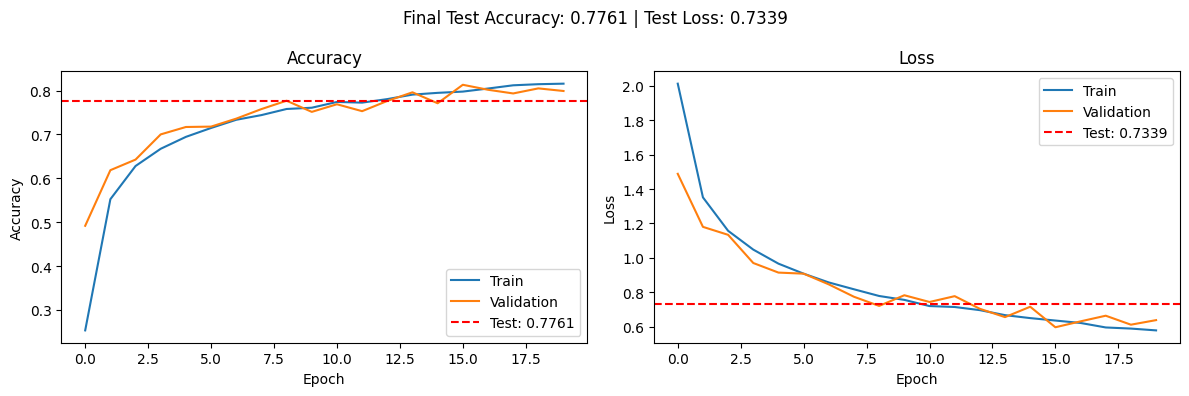

In [35]:
plot_training(history, test_acc, test_loss)


### Attempt 2 - Observations

We got slightly better after normalizing the values between 0 and 1

# Attempt 3 - ANN - Deeper network

Let's try to make the network a little more deeper

In [36]:
tf.keras.backend.clear_session()

model3 = keras.Sequential([
    keras.Input(shape=(32, 32)),
    layers.Flatten(),
    layers.Dense(1024),
    layers.Activation('relu'),
    layers.Dense(512),
    layers.Activation('relu'),
    layers.Dense(256),
    layers.Activation('relu'),
    layers.Dense(128),
    layers.Activation('relu'),
    layers.Dense(10, activation='softmax')
])

In [37]:
model3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [38]:
history3 = model3.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.1937 - loss: 2.1039 - val_accuracy: 0.3846 - val_loss: 1.7235
Epoch 2/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4704 - loss: 1.5101 - val_accuracy: 0.5550 - val_loss: 1.3380
Epoch 3/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5516 - loss: 1.3133 - val_accuracy: 0.5829 - val_loss: 1.2340
Epoch 4/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5804 - loss: 1.2403 - val_accuracy: 0.5596 - val_loss: 1.2864
Epoch 5/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5995 - loss: 1.1953 - val_accuracy: 0.6215 - val_loss: 1.1428
Epoch 6/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6126 - loss: 1.1569 - val_accuracy: 0.5418 - val_loss: 1.3641
Epoch 7/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6177 - loss: 1.1465 - val_accuracy: 0.6099 - val_loss: 1.1586
Epoch 8/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6296 - loss: 1.1132 - val_accuracy: 

In [39]:
test_loss, test_acc = model3.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss:     {test_loss:.4f}")

Test accuracy: 0.6644
Test loss:     1.0197


### Attempt 3 - Observations

Not much improvement

# Attempt 4 - ANN - Drop the validation data

In [41]:
tf.keras.backend.clear_session()

model4 = keras.Sequential([
    keras.Input(shape=(32, 32)),      # ← clean way in Keras 3
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])


In [42]:
model4.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [43]:
# if you see i am trying without passing validation data.
history4 = model4.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    verbose=1
)

Epoch 1/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.1524 - loss: 2.2225
Epoch 2/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4292 - loss: 1.6177
Epoch 3/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5488 - loss: 1.3472
Epoch 4/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6084 - loss: 1.2034
Epoch 5/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6394 - loss: 1.1227
Epoch 6/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6618 - loss: 1.0664
Epoch 7/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6759 - loss: 1.0240
Epoch 8/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6802 - loss: 1.0087
Epoch 9/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6893 - loss: 0.9798
Epoch 10/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6928 - loss: 0.9668
Epoch 11/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7017 - loss: 0.9438
Epoch 12/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step

In [45]:
test_loss, test_acc = model4.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss:     {test_loss:.4f}")

Test accuracy: 0.7043
Test loss:     0.9339


### Attempt 4 - Observations

Training is much faster without the validation dataset and we are able to get the similar levels of accuracy.



# Attempt 5 - ANN - Batch normalization

In [46]:
tf.keras.backend.clear_session()

model5 = keras.Sequential([
    keras.Input(shape=(32, 32)),
    layers.Flatten(),

    layers.Dense(1024),
    layers.BatchNormalization(),    # ← new
    layers.Activation('relu'),

    layers.Dense(512),
    layers.BatchNormalization(),    # ← new
    layers.Activation('relu'),

    layers.Dense(256),
    layers.BatchNormalization(),    # ← new
    layers.Activation('relu'),

    layers.Dense(128),
    layers.BatchNormalization(),    # ← new
    layers.Activation('relu'),

    layers.Dense(10, activation='softmax')
])

In [47]:
model5.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [51]:
history5 = model5.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    verbose=1
)

Epoch 1/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9240 - loss: 0.2283
Epoch 2/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9285 - loss: 0.2146
Epoch 3/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9297 - loss: 0.2078
Epoch 4/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9332 - loss: 0.1998
Epoch 5/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9380 - loss: 0.1855
Epoch 6/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9398 - loss: 0.1811
Epoch 7/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9415 - loss: 0.1738
Epoch 8/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9426 - loss: 0.1697
Epoch 9/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9442 - loss: 0.1667
Epoch 10/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9463 - loss: 0.1571
Epoch 11/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9500 - loss: 0.1486
Epoch 12/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step

In [52]:
test_loss, test_acc = model5.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss:     {test_loss:.4f}")

Test accuracy: 0.7652
Test loss:     0.9301


### Attempt 5 - observations

Even though we got 96% accuracy test accuracy ois 0.76 only. The model clearly overfit the training data and does not perform so well on test data.

# CNN - Attempt 1

In [4]:
# ANN used:  (42000, 32, 32)      → flat
# CNN needs: (42000, 32, 32, 1)   → with channel dim

X_train_cnn = X_train[..., tf.newaxis]
X_test_cnn  = X_test[..., tf.newaxis]

print(f"X_train_cnn shape: {X_train_cnn.shape}")
print(f"X_test_cnn shape:  {X_test_cnn.shape}")

X_train_cnn shape: (42000, 32, 32, 1)
X_test_cnn shape:  (18000, 32, 32, 1)


In [5]:
tf.keras.backend.clear_session()

model = keras.Sequential([
    keras.Input(shape=(32, 32, 1)),

    # Conv Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Conv Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Conv Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.25),

    # Classifier
    layers.Flatten(),
    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,194,570 (8.37 MB)

 Trainable params: 2,193,610 (8.37 MB)

 Non-trainable params: 960 (3.75 KB)

In [6]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    X_train_cnn, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - accuracy: 0.6445 - loss: 1.0904 - val_accuracy: 0.8571 - val_loss: 0.4747
Epoch 2/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8223 - loss: 0.5567 - val_accuracy: 0.8876 - val_loss: 0.3697
Epoch 3/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8514 - loss: 0.4739 - val_accuracy: 0.9012 - val_loss: 0.3280
Epoch 4/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8696 - loss: 0.4166 - val_accuracy: 0.8755 - val_loss: 0.3939
Epoch 5/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8797 - loss: 0.3829 - val_accuracy: 0.9140 - val_loss: 0.2907
Epoch 6/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8897 - loss: 0.3540 - val_accuracy: 0.9083 - val_loss: 0.3071
Epoch 7/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8971 - loss: 0.3282 - val_accuracy: 0.9221 - val_loss: 0.2636
Epoch 8/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9045 - loss: 0.3033 - val_ac

In [7]:
test_loss, test_acc = model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss:     {test_loss:.4f}")

Test accuracy: 0.9414
Test loss:     0.3027


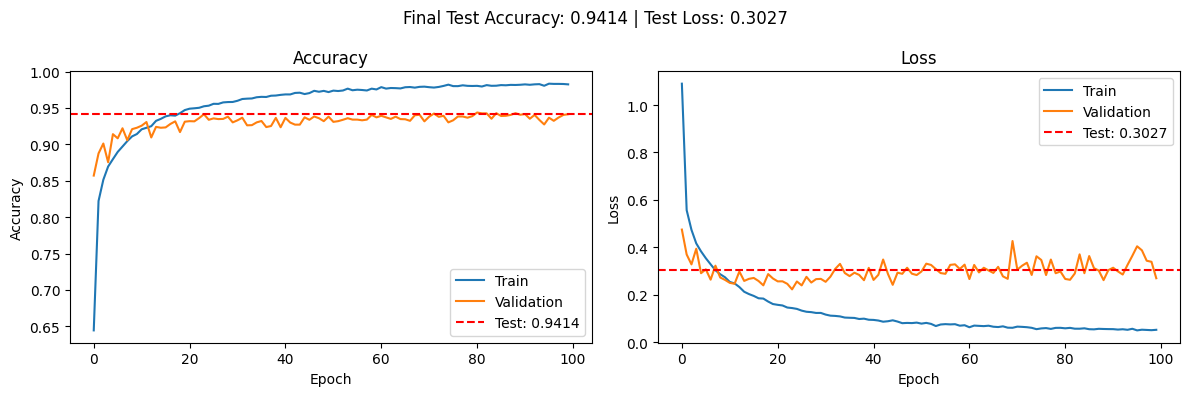

In [8]:
plot_training(history, test_acc, test_loss)

# CNN - Take 2

In [9]:
model = keras.Sequential([
    keras.Input(shape=(32, 32, 1)),

    # Conv Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Conv Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Conv Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.25),

    # Classifier
    layers.Flatten(),
    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,194,570 (8.37 MB)

 Trainable params: 2,193,610 (8.37 MB)

 Non-trainable params: 960 (3.75 KB)

In [10]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Compiled!")

Compiled!


In [11]:
callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=0.00001,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
]

In [12]:
history = model.fit(
    X_train_cnn, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.6385 - loss: 1.1044 - val_accuracy: 0.8631 - val_loss: 0.4485 - learning_rate: 0.0010
Epoch 2/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8212 - loss: 0.5649 - val_accuracy: 0.8900 - val_loss: 0.3852 - learning_rate: 0.0010
Epoch 3/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8490 - loss: 0.4766 - val_accuracy: 0.8979 - val_loss: 0.3499 - learning_rate: 0.0010
Epoch 4/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8649 - loss: 0.4253 - val_accuracy: 0.8964 - val_loss: 0.3422 - learning_rate: 0.0010
Epoch 5/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8794 - loss: 0.3878 - val_accuracy: 0.8917 - val_loss: 0.3483 - learning_rate: 0.0010
Epoch 6/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8884 - loss: 0.3537 - val_accuracy: 0.9060 - val_loss: 0.3089 - learning_rate: 0.0010
Epoch 7/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8971 - loss: 

In [13]:
test_loss, test_acc = model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss:     {test_loss:.4f}")

Test accuracy: 0.9416
Test loss:     0.2391


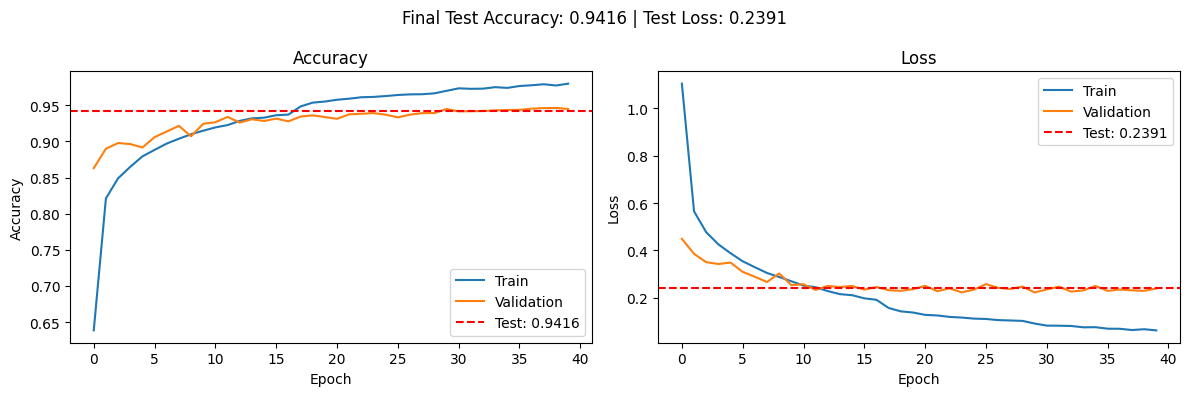

In [14]:
plot_training(history, test_acc, test_loss)

# CNN - Take 3 - Data Augmentation

In [15]:
model = keras.Sequential([
    keras.Input(shape=(32, 32, 1)),

    # Data Augmentation — only active during training
    layers.RandomRotation(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.1),

    # Conv Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Conv Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Conv Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.25),

    # Classifier
    layers.Flatten(),
    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ (None, 32, 32, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 32, 32, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             

 Total params: 2,194,570 (8.37 MB)

 Trainable params: 2,193,610 (8.37 MB)

 Non-trainable params: 960 (3.75 KB)

In [16]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Compiled!")

Compiled!


In [17]:
callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=0.00001,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
]

In [18]:
history = model.fit(
    X_train_cnn, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.3710 - loss: 1.8455 - val_accuracy: 0.6762 - val_loss: 0.9966 - learning_rate: 0.0010
Epoch 2/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.6410 - loss: 1.0764 - val_accuracy: 0.8410 - val_loss: 0.5124 - learning_rate: 0.0010
Epoch 3/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7040 - loss: 0.8968 - val_accuracy: 0.8764 - val_loss: 0.4192 - learning_rate: 0.0010
Epoch 4/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7335 - loss: 0.8181 - val_accuracy: 0.8543 - val_loss: 0.4610 - learning_rate: 0.0010
Epoch 5/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7586 - loss: 0.7464 - val_accuracy: 0.8621 - val_loss: 0.4450 - learning_rate: 0.0010
Epoch 6/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7742 - loss: 0.7079 - val_accuracy: 0.8614 - val_loss: 0.4396 - learning_rate: 0.0010
Epoch 7/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.78

In [19]:
test_loss, test_acc = model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss:     {test_loss:.4f}")

Test accuracy: 0.9451
Test loss:     0.1941


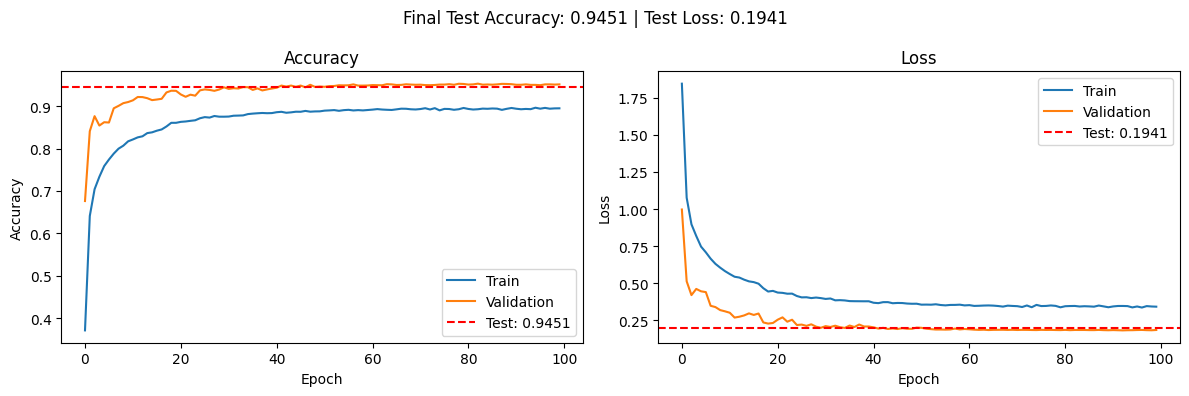

In [20]:
plot_training(history, test_acc, test_loss)
